<a href="https://colab.research.google.com/github/ashasmushtaque-boop/Task-2-Predict-Future-Stock-Prices-Short-Term-/blob/main/Task_2_Predict_Future_Stock_Prices_(Short_Term).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [ ]:
stock = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

stock.head()


/tmp/ipython-input-1364/3218687048.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [ ]:
stock["Next_Close"] = stock["Close"].shift(-1)

stock = stock.dropna()

stock.head()


Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,71.696625
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,72.267921
2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200,71.928055
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000,73.085114
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200,74.637497


In [ ]:
X = stock[["Open", "High", "Low", "Volume"]]


In [ ]:
y = stock["Next_Close"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)


LinearRegression()

In [ ]:
lr_predictions = lr_model.predict(X_test)


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)


In [ ]:
lr_error = mean_squared_error(y_test, lr_predictions)
rf_error = mean_squared_error(y_test, rf_predictions)

print("Linear Regression Error:", lr_error)
print("Random Forest Error:", rf_error)


Linear Regression Error: 9.62018052002753
Random Forest Error: 666.9356652246701


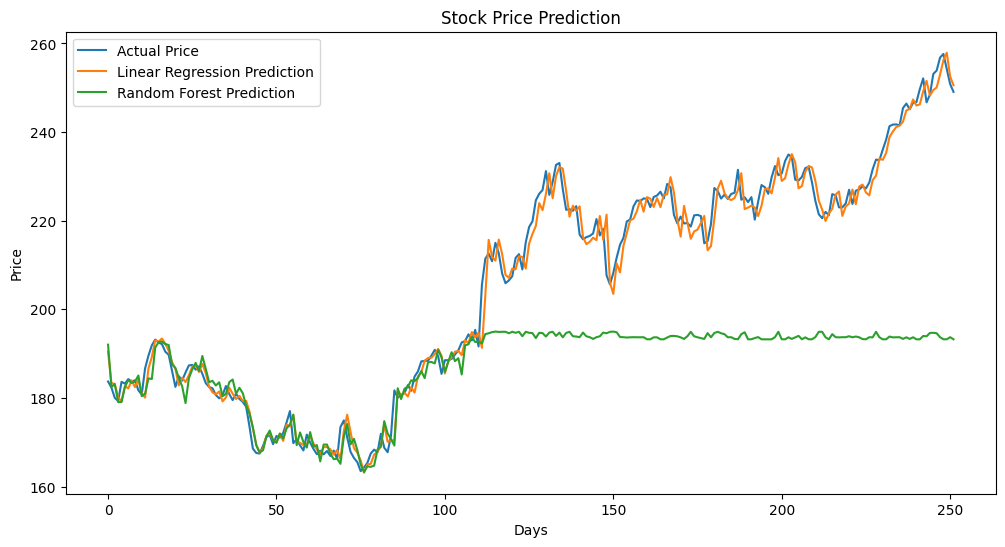

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(lr_predictions, label="Linear Regression Prediction")
plt.plot(rf_predictions, label="Random Forest Prediction")

plt.legend()
plt.title("Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")

plt.show()
